In [1]:
import joblib
import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import Crippen
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.QED import qed

In [4]:
prediction = pd.read_csv("data_prediction.csv")

print("="*60)
print("Prediction Dataset")
print("="*60)

print("Shape :", prediction.shape)

display(prediction.head())

Prediction Dataset
Shape : (1626, 9)


,CID,SMILES,InChIKey,PubChem_Status,Senyawa,IC50,Unit,Assay_ID,Assay_Description
0,92139,CC1=CC=C(C=C1)C(C)CCC=C(C)C,VMYXUZSZMNBRCN-UHFFFAOYSA-N,FOUND,alpha-Curcumene,NaN,NaN,NaN,NaN
1,6428461,CC1=CCC(=CC1)C(C)CCC=C(C)C,JXZQZARENYGJMK-UHFFFAOYSA-N,FOUND,beta-curcumene,NaN,NaN,NaN,NaN
2,10399139,C[C@H]1CC[C@@H]2[C@]13CC(=C(C)C)[C@](O3)(CC2=C)O,DEBDFZGNZTYPMF-NZBPQXDJSA-N,FOUND,Isocurcumenol,NaN,NaN,NaN,NaN
3,14106072,C[C@H]1CC/C=C(\CC(=O)[C@@H](CC1=O)C(C)C)/C,KDPFMRXIVDLQKX-ISGXEFFDSA-N,FOUND,Curdione,NaN,NaN,NaN,NaN
4,6452096,CCOC(=O)CC[C@@H](C)[C@H]1CC[C@@H]2[C@@]1([C@H]...,FPDXMWHJGOCDQJ-HZAMXZRMSA-N,FOUND,Ethyl iso-allocholate,NaN,NaN,NaN,NaN


In [5]:
print("="*60)
print("Prediction Dataset QC")
print("="*60)

print(f"Total compounds      : {len(prediction)}")
print(f"Missing SMILES       : {prediction['SMILES'].isna().sum()}")
print(f"Duplicate SMILES     : {prediction['SMILES'].duplicated().sum()}")

prediction["Mol"] = prediction["SMILES"].apply(Chem.MolFromSmiles)

invalid = prediction["Mol"].isna().sum()

print(f"Invalid SMILES       : {invalid}")

assert invalid == 0, "Masih ada SMILES invalid!"

Prediction Dataset QC
Total compounds      : 1626
Missing SMILES       : 0
Duplicate SMILES     : 239
Invalid SMILES       : 0


In [6]:
prediction[prediction["SMILES"].duplicated(keep=False)] \
    .sort_values("SMILES") \
    [["CID","Senyawa","SMILES"]].head(20)

,CID,Senyawa,SMILES
1614,311,citric acid,C(C(=O)O)C(CC(=O)O)(C(=O)O)O
33,311,Citric acid,C(C(=O)O)C(CC(=O)O)(C(=O)O)O
945,1110,Succinic acid,C(CC(=O)O)C(=O)O
1419,1110,succinic acid,C(CC(=O)O)C(=O)O
848,5793,Glucose,C([C@@H]1[C@H]([C@@H]([C@H](C(O1)O)O)O)O)O
30,5793,D-Glucose,C([C@@H]1[C@H]([C@@H]([C@H](C(O1)O)O)O)O)O
1417,23274265,humulene epoxide II,C/C/1=C/CC(/C=C\CC2(C(O2)CC1)C)(C)C
685,23274265,Humulene epoxide II,C/C/1=C/CC(/C=C\CC2(C(O2)CC1)C)(C)C
1039,5281520,alpha-Caryophyllene,C/C/1=C\CC(/C=C/C/C(=C/CC1)/C)(C)C
641,5281520,alpha-Humulene,C/C/1=C\CC(/C=C/C/C(=C/CC1)/C)(C)C


In [7]:
prediction = prediction.drop_duplicates(
    subset="SMILES",
    keep="first"
).reset_index(drop=True)

print("After removing duplicates :", len(prediction))

After removing duplicates : 1387


In [8]:
fingerprints = []

for mol in prediction["Mol"]:

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=2,
        nBits=2048
    )

    fingerprints.append(list(fp))

fp_df = pd.DataFrame(
    fingerprints,
    columns=[f"Bit_{i}" for i in range(2048)]
)

print(fp_df.shape)

[03:11:50] DEPRECATION WARNING: please use MorganGenerator
[03:11:50] DEPRECATION WARNING: please use MorganGenerator
[03:11:50] DEPRECATION WARNING: please use MorganGenerator
[03:11:50] DEPRECATION WARNING: please use MorganGenerator
[03:11:50] DEPRECATION WARNING: please use MorganGenerator
[03:11:50] DEPRECATION WARNING: please use MorganGenerator
[03:11:50] DEPRECATION WARNING: please use MorganGenerator
[03:11:50] DEPRECATION WARNING: please use MorganGenerator
[03:11:50] DEPRECATION WARNING: please use MorganGenerator
[03:11:50] DEPRECATION WARNING: please use MorganGenerator
[03:11:50] DEPRECATION WARNING: please use MorganGenerator
[03:11:50] DEPRECATION WARNING: please use MorganGenerator
[03:11:50] DEPRECATION WARNING: please use MorganGenerator
[03:11:50] DEPRECATION WARNING: please use MorganGenerator
[03:11:50] DEPRECATION WARNING: please use MorganGenerator
[03:11:50] DEPRECATION WARNING: please use MorganGenerator
[03:11:50] DEPRECATION WARNING: please use MorganGenerat

(1387, 2048)


In [9]:
descriptor_df = pd.DataFrame({

    "MW": prediction["Mol"].apply(Descriptors.MolWt),

    "SlogP": prediction["Mol"].apply(Crippen.MolLogP),

    "TPSA": prediction["Mol"].apply(rdMolDescriptors.CalcTPSA),

    "HBA": prediction["Mol"].apply(rdMolDescriptors.CalcNumHBA),

    "HBD": prediction["Mol"].apply(rdMolDescriptors.CalcNumHBD),

    "RotatableBonds": prediction["Mol"].apply(
        rdMolDescriptors.CalcNumRotatableBonds
    ),

    "AromaticRings": prediction["Mol"].apply(
        rdMolDescriptors.CalcNumAromaticRings
    ),

    "FractionCsp3": prediction["Mol"].apply(
        rdMolDescriptors.CalcFractionCSP3
    ),

    "MolarRefractivity": prediction["Mol"].apply(
        Crippen.MolMR
    ),

    "QED": prediction["Mol"].apply(qed),

    "HeteroatomRatio": prediction["Mol"].apply(
        lambda m:
        rdMolDescriptors.CalcNumHeteroatoms(m) /
        m.GetNumAtoms()
        if m.GetNumAtoms() > 0 else 0
    )

})

print(descriptor_df.shape)

(1387, 11)


In [10]:
X_prediction = pd.concat(
    [fp_df, descriptor_df],
    axis=1
)

print(X_prediction.shape)

(1387, 2059)


In [12]:
import joblib

model = joblib.load("ET_best_model.pkl")

print("Model loaded!")

Model loaded!


In [13]:
print((X_prediction.columns == model.feature_names_in_).all())

True


In [14]:
prediction["Predicted_Label"] = model.predict(X_prediction)

prediction["Probability_Active"] = model.predict_proba(X_prediction)[:,1]

prediction.head()

,CID,SMILES,InChIKey,PubChem_Status,Senyawa,IC50,Unit,Assay_ID,Assay_Description,Mol,Predicted_Label,Probability_Active
0,92139,CC1=CC=C(C=C1)C(C)CCC=C(C)C,VMYXUZSZMNBRCN-UHFFFAOYSA-N,FOUND,alpha-Curcumene,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,0,0.080
1,6428461,CC1=CCC(=CC1)C(C)CCC=C(C)C,JXZQZARENYGJMK-UHFFFAOYSA-N,FOUND,beta-curcumene,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,0,0.176
2,10399139,C[C@H]1CC[C@@H]2[C@]13CC(=C(C)C)[C@](O3)(CC2=C)O,DEBDFZGNZTYPMF-NZBPQXDJSA-N,FOUND,Isocurcumenol,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,0,0.196
3,14106072,C[C@H]1CC/C=C(\CC(=O)[C@@H](CC1=O)C(C)C)/C,KDPFMRXIVDLQKX-ISGXEFFDSA-N,FOUND,Curdione,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,0,0.154
4,6452096,CCOC(=O)CC[C@@H](C)[C@H]1CC[C@@H]2[C@@]1([C@H]...,FPDXMWHJGOCDQJ-HZAMXZRMSA-N,FOUND,Ethyl iso-allocholate,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,0,0.390


In [15]:
print("="*60)
print("Prediction Summary")
print("="*60)

print(prediction["Predicted_Label"].value_counts())

print()

print(
    prediction["Predicted_Label"]
    .value_counts(normalize=True)
    *100
)

Prediction Summary
Predicted_Label
0    1377
1      10
Name: count, dtype: int64

Predicted_Label
0    99.279019
1     0.720981
Name: proportion, dtype: float64


In [16]:
prediction = prediction.sort_values(
    "Probability_Active",
    ascending=False
).reset_index(drop=True)

prediction.head(20)

,CID,SMILES,InChIKey,PubChem_Status,Senyawa,IC50,Unit,Assay_ID,Assay_Description,Mol,Predicted_Label,Probability_Active
0,11575632,COC[C@@H](CC1=CC(=C(C=C1)OC)OC)[C@H](CC2=CC3=C...,RCFGIEPQSDGMJJ-RTBURBONSA-N,FOUND,Niranthin,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.652
1,145455759,CC(C)[C@@H](C(=O)O)NC(=O)[C@H](CCCN=C(N)N)NC(=...,TTZAWSKKNCEINZ-AVGNSLFASA-N,FOUND,His Arg Val,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.642
2,135398712,CCC1=C(C2=NC1=CC3=C(C4=C([C@@H](C(=C5[C@H]([C@...,FDHFJXKRMIVNCQ-OSIZZBRKSA-N,FOUND,Pheophytin a,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.594
3,145455853,CC(C)[C@@H](C(=O)O)NC(=O)CNC(=O)[C@H](CC1=CN=C...,NTXIJPDAHXSHNL-ONGXEEELSA-N,FOUND,His Gly Val,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.592
4,145453664,C[C@@H](C(=O)N[C@@H](CO)C(=O)N[C@@H](CC1=CN=CN...,NHWYNIZWLJYZAG-XVYDVKMFSA-N,FOUND,Ala Ser His,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.586
5,135407446,CCC\1=C2C=C3C(=C4C(=O)[C@@H](C(=C5[C@H]([C@@H]...,AMVFDCTXPYHACR-KMFDAVQUSA-N,FOUND,Pheophytin b,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.586
6,11593175,CCC1=C(C2=NC1=CC3=C(C4=C([N-]3)C(=C5[C@H]([C@@...,NSMUHPMZFPKNMZ-VBYMZDBQSA-M,FOUND,Chlorophyll b,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.572
7,185904,C1=CC=C(C=C1)C[C@@H](CO)NC(=O)[C@H](CC2=CC=CC=...,KSVKECXWDNCRTM-GOTSBHOMSA-N,FOUND,aurantiamide,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.568
8,12085802,CCC1=C(C2=NC1=CC3=C(C4=C([N-]3)C(=C5[C@H]([C@@...,ATNHDLDRLWWWCB-AENOIHSZSA-M,FOUND,Chlorophyll a,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.546
9,162941351,CCC1=C(C2=NC1=CC3=C(C4=C(N3)C(=C5[C@@H]([C@@H]...,PRZIBWPFVNBJRQ-URYQECEPSA-N,FOUND,Aristophyll-C,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.506


In [17]:
prediction.to_csv(
    "prediction_results.csv",
    index=False
)

print("Prediction results saved.")

Prediction results saved.


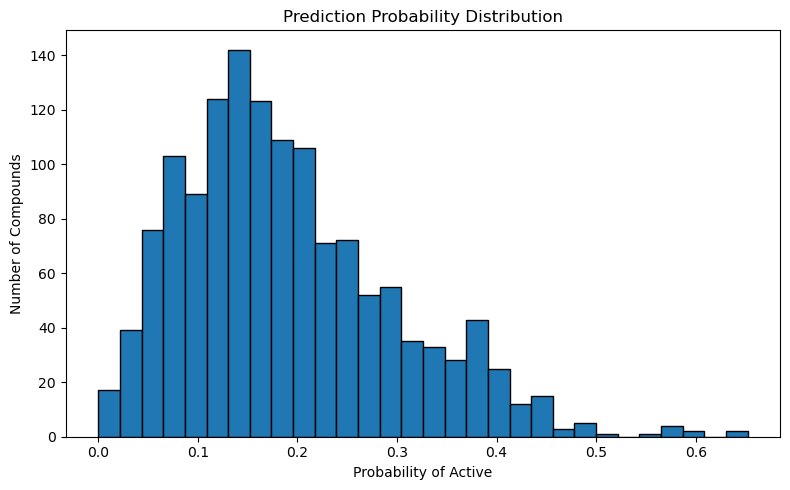

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    prediction["Probability_Active"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Probability of Active")
plt.ylabel("Number of Compounds")
plt.title("Prediction Probability Distribution")

plt.tight_layout()

plt.show()

In [19]:
prediction[
    [
        "CID",
        "Senyawa",
        "Probability_Active",
        "Predicted_Label"
    ]
].head(20)

,CID,Senyawa,Probability_Active,Predicted_Label
0,11575632,Niranthin,0.652,1
1,145455759,His Arg Val,0.642,1
2,135398712,Pheophytin a,0.594,1
3,145455853,His Gly Val,0.592,1
4,145453664,Ala Ser His,0.586,1
5,135407446,Pheophytin b,0.586,1
6,11593175,Chlorophyll b,0.572,1
7,185904,aurantiamide,0.568,1
8,12085802,Chlorophyll a,0.546,1
9,162941351,Aristophyll-C,0.506,1


AD

In [20]:
import joblib
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem import AllChem

In [21]:
train = pd.read_csv("cyp3a4_binary_final_dataset.csv")

prediction = pd.read_csv("prediction_results.csv")

print(train.shape)
print(prediction.shape)

(1756, 8)
(1387, 12)


In [22]:
train["Mol"] = train["SMILES"].apply(Chem.MolFromSmiles)

prediction["Mol"] = prediction["SMILES"].apply(Chem.MolFromSmiles)

In [23]:
train_fp = []

for mol in train["Mol"]:

    train_fp.append(
        AllChem.GetMorganFingerprintAsBitVect(
            mol,
            radius=2,
            nBits=2048
        )
    )

prediction_fp = []

for mol in prediction["Mol"]:

    prediction_fp.append(
        AllChem.GetMorganFingerprintAsBitVect(
            mol,
            radius=2,
            nBits=2048
        )
    )

[03:27:37] DEPRECATION WARNING: please use MorganGenerator
[03:27:37] DEPRECATION WARNING: please use MorganGenerator
[03:27:37] DEPRECATION WARNING: please use MorganGenerator
[03:27:37] DEPRECATION WARNING: please use MorganGenerator
[03:27:37] DEPRECATION WARNING: please use MorganGenerator
[03:27:37] DEPRECATION WARNING: please use MorganGenerator
[03:27:37] DEPRECATION WARNING: please use MorganGenerator
[03:27:37] DEPRECATION WARNING: please use MorganGenerator
[03:27:37] DEPRECATION WARNING: please use MorganGenerator
[03:27:37] DEPRECATION WARNING: please use MorganGenerator
[03:27:37] DEPRECATION WARNING: please use MorganGenerator
[03:27:37] DEPRECATION WARNING: please use MorganGenerator
[03:27:37] DEPRECATION WARNING: please use MorganGenerator
[03:27:37] DEPRECATION WARNING: please use MorganGenerator
[03:27:37] DEPRECATION WARNING: please use MorganGenerator
[03:27:37] DEPRECATION WARNING: please use MorganGenerator
[03:27:37] DEPRECATION WARNING: please use MorganGenerat

In [24]:
max_similarity = []

for fp in prediction_fp:

    sims = DataStructs.BulkTanimotoSimilarity(
        fp,
        train_fp
    )

    max_similarity.append(
        max(sims)
    )

prediction["Max_Similarity"] = max_similarity

In [25]:
print("="*60)
print("Maximum Similarity Statistics")
print("="*60)

print(
    prediction["Max_Similarity"].describe()
)

Maximum Similarity Statistics
count    1387.000000
mean        0.284148
std         0.120990
min         0.032258
25%         0.192982
50%         0.260000
75%         0.338132
max         1.000000
Name: Max_Similarity, dtype: float64


In [26]:
prediction["Domain"] = np.where(

    prediction["Max_Similarity"] >= 0.40,

    "In-domain",

    "Out-of-domain"

)

In [27]:
print("="*60)
print("Prediction Applicability Domain")
print("="*60)

print(
    prediction["Domain"].value_counts()
)

print()

print(
    prediction.groupby("Domain")["Max_Similarity"]
    .describe()
)

Prediction Applicability Domain
Domain
Out-of-domain    1181
In-domain         206
Name: count, dtype: int64

                count      mean       std       min       25%      50%  \
Domain                                                                   
In-domain       206.0  0.502834  0.111209  0.400000  0.426996  0.47541   
Out-of-domain  1181.0  0.246004  0.072391  0.032258  0.186047  0.24000   

                    75%       max  
Domain                             
In-domain      0.543184  1.000000  
Out-of-domain  0.305556  0.397059  


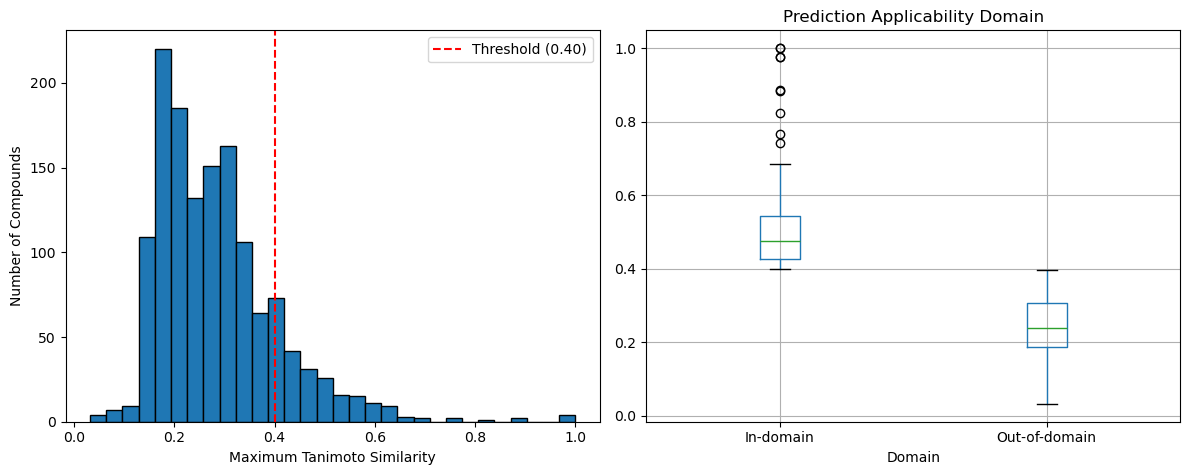

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

# Histogram

axes[0].hist(
    prediction["Max_Similarity"],
    bins=30,
    edgecolor="black"
)

axes[0].axvline(
    0.40,
    color="red",
    linestyle="--",
    label="Threshold (0.40)"
)

axes[0].set_xlabel("Maximum Tanimoto Similarity")
axes[0].set_ylabel("Number of Compounds")
axes[0].legend()

# Boxplot

prediction.boxplot(

    column="Max_Similarity",

    by="Domain",

    ax=axes[1]

)

axes[1].set_title("Prediction Applicability Domain")

plt.suptitle("")

plt.tight_layout()

plt.show()

In [29]:
top_candidates = prediction[

    (prediction["Predicted_Label"]==1)

    &

    (prediction["Domain"]=="In-domain")

].sort_values(

    "Probability_Active",

    ascending=False

)

display(

    top_candidates[
        [

            "CID",

            "Senyawa",

            "Probability_Active",

            "Max_Similarity",

            "Domain"

        ]

    ]

)

,CID,Senyawa,Probability_Active,Max_Similarity,Domain
0,11575632,Niranthin,0.652,0.528302,In-domain


In [30]:
print("="*60)
print("Prediction Applicability Domain Summary")
print("="*60)

print(prediction["Domain"].value_counts())

print()

print(
    prediction.groupby("Domain")["Max_Similarity"]
    .describe()
)

Prediction Applicability Domain Summary
Domain
Out-of-domain    1181
In-domain         206
Name: count, dtype: int64

                count      mean       std       min       25%      50%  \
Domain                                                                   
In-domain       206.0  0.502834  0.111209  0.400000  0.426996  0.47541   
Out-of-domain  1181.0  0.246004  0.072391  0.032258  0.186047  0.24000   

                    75%       max  
Domain                             
In-domain      0.543184  1.000000  
Out-of-domain  0.305556  0.397059  


In [31]:
top_candidates = prediction[
    (prediction["Predicted_Label"] == 1) &
    (prediction["Domain"] == "In-domain")
].sort_values(
    "Probability_Active",
    ascending=False
)

display(
    top_candidates[
        [
            "CID",
            "Senyawa",
            "Probability_Active",
            "Max_Similarity"
        ]
    ]
)

,CID,Senyawa,Probability_Active,Max_Similarity
0,11575632,Niranthin,0.652,0.528302


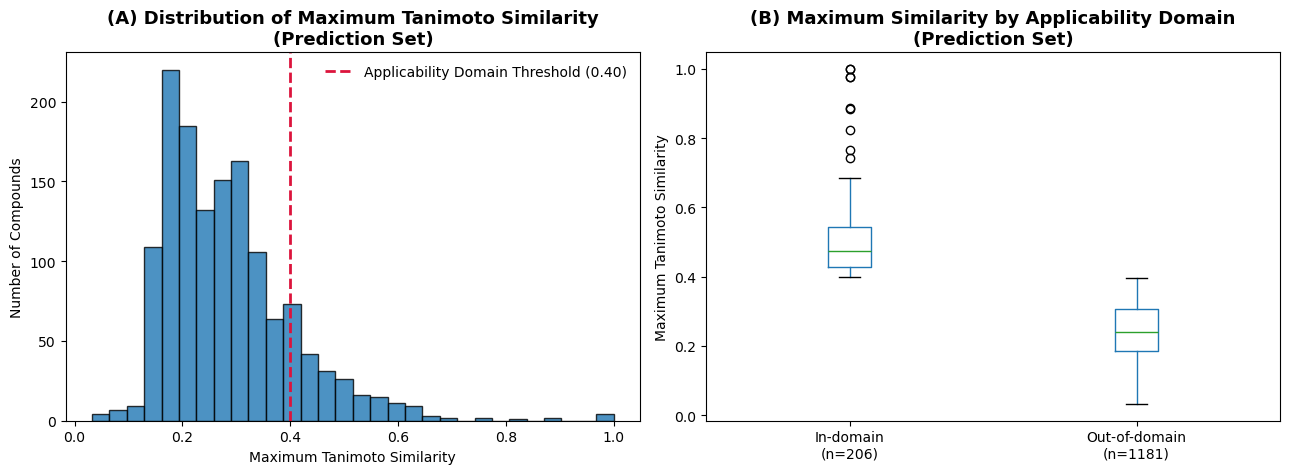

In [32]:
import matplotlib.pyplot as plt

# ==============================
# Figure: Prediction Applicability Domain
# ==============================

threshold = 0.40

n_in = (prediction["Domain"] == "In-domain").sum()
n_out = (prediction["Domain"] == "Out-of-domain").sum()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13,5)
)

# ======================================
# (A) Histogram
# ======================================

axes[0].hist(
    prediction["Max_Similarity"],
    bins=30,
    edgecolor="black",
    alpha=0.8
)

axes[0].axvline(
    threshold,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Applicability Domain Threshold ({threshold:.2f})"
)

axes[0].set_title(
    "(A) Distribution of Maximum Tanimoto Similarity\n(Prediction Set)",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_xlabel("Maximum Tanimoto Similarity")
axes[0].set_ylabel("Number of Compounds")

axes[0].legend(frameon=False)

# ======================================
# (B) Boxplot
# ======================================

prediction.boxplot(
    column="Max_Similarity",
    by="Domain",
    ax=axes[1],
    grid=False
)

axes[1].set_title(
    "(B) Maximum Similarity by Applicability Domain\n(Prediction Set)",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_xlabel("")
axes[1].set_ylabel("Maximum Tanimoto Similarity")

axes[1].set_xticklabels([
    f"In-domain\n(n={n_in})",
    f"Out-of-domain\n(n={n_out})"
])

# Hilangkan title bawaan pandas
plt.suptitle("")

plt.tight_layout()

plt.savefig(
    "Figure6_Prediction_Applicability_Domain.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [33]:
# ==========================================================
# Predicted Active Herbal Compounds
# ==========================================================

predicted_active = prediction[
    prediction["Predicted_Label"] == 1
].copy()

predicted_active = predicted_active.sort_values(
    "Probability_Active",
    ascending=False
).reset_index(drop=True)

print("="*60)
print("Predicted Active Herbal Compounds")
print("="*60)

print(f"Total predicted active compounds : {len(predicted_active)}")

display(
    predicted_active[
        [
            "CID",
            "Senyawa",
            "Probability_Active",
            "Max_Similarity",
            "Domain"
        ]
    ]
)

Predicted Active Herbal Compounds
Total predicted active compounds : 10


,CID,Senyawa,Probability_Active,Max_Similarity,Domain
0,11575632,Niranthin,0.652,0.528302,In-domain
1,145455759,His Arg Val,0.642,0.309278,Out-of-domain
2,135398712,Pheophytin a,0.594,0.166667,Out-of-domain
3,145455853,His Gly Val,0.592,0.314607,Out-of-domain
4,145453664,Ala Ser His,0.586,0.294872,Out-of-domain
5,135407446,Pheophytin b,0.586,0.166667,Out-of-domain
6,11593175,Chlorophyll b,0.572,0.185897,Out-of-domain
7,185904,aurantiamide,0.568,0.306452,Out-of-domain
8,12085802,Chlorophyll a,0.546,0.181818,Out-of-domain
9,162941351,Aristophyll-C,0.506,0.200000,Out-of-domain


In [34]:
# ==========================================================
# High Confidence Herbal Candidates
# ==========================================================

high_confidence = predicted_active[
    predicted_active["Domain"] == "In-domain"
].copy()

print("="*60)
print("High Confidence Herbal Candidates")
print("="*60)

print(f"Total high confidence candidates : {len(high_confidence)}")

display(
    high_confidence[
        [
            "CID",
            "Senyawa",
            "Probability_Active",
            "Max_Similarity",
            "Domain"
        ]
    ]
)

High Confidence Herbal Candidates
Total high confidence candidates : 1


,CID,Senyawa,Probability_Active,Max_Similarity,Domain
0,11575632,Niranthin,0.652,0.528302,In-domain


In [35]:
# ==========================================================
# Screening Summary
# ==========================================================

summary = pd.DataFrame({

    "Category":[

        "Total Herbal Compounds",

        "Predicted Active",

        "Predicted Inactive",

        "In-domain",

        "Out-of-domain",

        "High Confidence Candidate"

    ],

    "Count":[

        len(prediction),

        (prediction["Predicted_Label"]==1).sum(),

        (prediction["Predicted_Label"]==0).sum(),

        (prediction["Domain"]=="In-domain").sum(),

        (prediction["Domain"]=="Out-of-domain").sum(),

        len(high_confidence)

    ]

})

summary["Percentage"] = (
    summary["Count"] /
    len(prediction) *100
).round(2)

display(summary)

,Category,Count,Percentage
0,Total Herbal Compounds,1387,100.00
1,Predicted Active,10,0.72
2,Predicted Inactive,1377,99.28
3,In-domain,206,14.85
4,Out-of-domain,1181,85.15
5,High Confidence Candidate,1,0.07


In [36]:
predicted_active.to_csv(
    "predicted_active_herbal_compounds.csv",
    index=False
)

high_confidence.to_csv(
    "high_confidence_herbal_candidates.csv",
    index=False
)

summary.to_csv(
    "prediction_screening_summary.csv",
    index=False
)

print("="*60)
print("Prediction Results Saved")
print("="*60)

print("✓ predicted_active_herbal_compounds.csv")
print("✓ high_confidence_herbal_candidates.csv")
print("✓ prediction_screening_summary.csv")

Prediction Results Saved
✓ predicted_active_herbal_compounds.csv
✓ high_confidence_herbal_candidates.csv
✓ prediction_screening_summary.csv


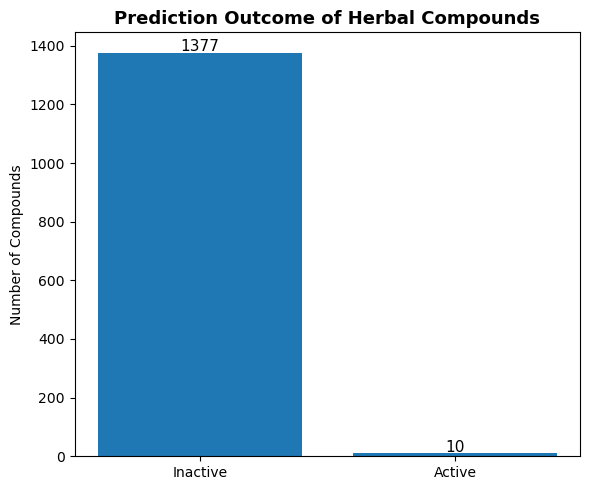

In [37]:
import matplotlib.pyplot as plt

labels = [
    "Inactive",
    "Active"
]

counts = [
    (prediction["Predicted_Label"]==0).sum(),
    (prediction["Predicted_Label"]==1).sum()
]

plt.figure(figsize=(6,5))

bars = plt.bar(
    labels,
    counts
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+5,
        f"{int(bar.get_height())}",
        ha="center",
        fontsize=11
    )

plt.ylabel("Number of Compounds")

plt.title(
    "Prediction Outcome of Herbal Compounds",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "Figure7_Prediction_Outcome.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [39]:
# Load dataset herbal asli
herbal = pd.read_csv("dataset herbal.csv")

# Merge berdasarkan nama senyawa
predicted_active_plants = predicted_active.merge(
    herbal[
        [
            "Nama Tanaman",
            "Nama Latin",
            "Bagian Tanaman",
            "Senyawa"
        ]
    ],
    on="Senyawa",
    how="left"
)

# Rapikan urutan kolom
predicted_active_plants = predicted_active_plants[
    [
        "CID",
        "Senyawa",
        "Nama Tanaman",
        "Nama Latin",
        "Bagian Tanaman",
        "Probability_Active",
        "Max_Similarity",
        "Domain"
    ]
]

display(predicted_active_plants)

,CID,Senyawa,Nama Tanaman,Nama Latin,Bagian Tanaman,Probability_Active,Max_Similarity,Domain
0,11575632,Niranthin,Meniran Hijau,Phyllanthus niruri,Seluruh tanaman,0.652,0.528302,In-domain
1,11575632,Niranthin,Meniran Hijau,Phyllanthus niruri,Herba,0.652,0.528302,In-domain
2,145455759,His Arg Val,Kucing-kucingan,Acalypha indica,Akar,0.642,0.309278,Out-of-domain
3,135398712,Pheophytin a,Bangun-bangun,Plectranthus amboinicus,Daun,0.594,0.166667,Out-of-domain
4,145455853,His Gly Val,Kucing-kucingan,Acalypha indica,Akar,0.592,0.314607,Out-of-domain
5,145453664,Ala Ser His,Kucing-kucingan,Acalypha indica,Akar,0.586,0.294872,Out-of-domain
6,135407446,Pheophytin b,Bangun-bangun,Plectranthus amboinicus,Daun,0.586,0.166667,Out-of-domain
7,11593175,Chlorophyll b,Pandan,Pandanus amaryllifolius,Daun,0.572,0.185897,Out-of-domain
8,11593175,Chlorophyll b,Bayam Merah,Amaranthus tricolor,Daun,0.572,0.185897,Out-of-domain
9,185904,aurantiamide,Tanaman Cakar Ayam,Selaginella doederleinii,Seluruh Tanaman,0.568,0.306452,Out-of-domain


In [40]:
# ==========================================================
# Active compounds and their source plants (Detailed)
# ==========================================================

herbal = pd.read_csv("dataset herbal.csv")

predicted_active_plants = predicted_active.merge(
    herbal[
        [
            "Nama Tanaman",
            "Nama Latin",
            "Bagian Tanaman",
            "Senyawa"
        ]
    ],
    on="Senyawa",
    how="left"
)

predicted_active_plants = predicted_active_plants[
    [
        "CID",
        "Senyawa",
        "Nama Tanaman",
        "Nama Latin",
        "Bagian Tanaman",
        "Probability_Active",
        "Max_Similarity",
        "Domain"
    ]
]

predicted_active_plants = predicted_active_plants.sort_values(
    ["Probability_Active","Nama Tanaman"],
    ascending=[False,True]
)

display(predicted_active_plants)

predicted_active_plants.to_csv(
    "predicted_active_herbal_plants_detail.csv",
    index=False
)

,CID,Senyawa,Nama Tanaman,Nama Latin,Bagian Tanaman,Probability_Active,Max_Similarity,Domain
0,11575632,Niranthin,Meniran Hijau,Phyllanthus niruri,Seluruh tanaman,0.652,0.528302,In-domain
1,11575632,Niranthin,Meniran Hijau,Phyllanthus niruri,Herba,0.652,0.528302,In-domain
2,145455759,His Arg Val,Kucing-kucingan,Acalypha indica,Akar,0.642,0.309278,Out-of-domain
3,135398712,Pheophytin a,Bangun-bangun,Plectranthus amboinicus,Daun,0.594,0.166667,Out-of-domain
4,145455853,His Gly Val,Kucing-kucingan,Acalypha indica,Akar,0.592,0.314607,Out-of-domain
6,135407446,Pheophytin b,Bangun-bangun,Plectranthus amboinicus,Daun,0.586,0.166667,Out-of-domain
5,145453664,Ala Ser His,Kucing-kucingan,Acalypha indica,Akar,0.586,0.294872,Out-of-domain
8,11593175,Chlorophyll b,Bayam Merah,Amaranthus tricolor,Daun,0.572,0.185897,Out-of-domain
7,11593175,Chlorophyll b,Pandan,Pandanus amaryllifolius,Daun,0.572,0.185897,Out-of-domain
9,185904,aurantiamide,Tanaman Cakar Ayam,Selaginella doederleinii,Seluruh Tanaman,0.568,0.306452,Out-of-domain


In [41]:
# ==========================================================
# Summary (One row per compound)
# ==========================================================

summary_plants = (
    predicted_active_plants
    .groupby(
        [
            "CID",
            "Senyawa",
            "Probability_Active",
            "Max_Similarity",
            "Domain"
        ],
        as_index=False
    )
    .agg({
        "Nama Tanaman": lambda x: ", ".join(sorted(x.dropna().unique())),
        "Nama Latin": lambda x: ", ".join(sorted(x.dropna().unique())),
        "Bagian Tanaman": lambda x: ", ".join(sorted(x.dropna().unique()))
    })
)

display(summary_plants)

summary_plants.to_csv(
    "predicted_active_herbal_plants_summary.csv",
    index=False
)

,CID,Senyawa,Probability_Active,Max_Similarity,Domain,Nama Tanaman,Nama Latin,Bagian Tanaman
0,185904,aurantiamide,0.568,0.306452,Out-of-domain,Tanaman Cakar Ayam,Selaginella doederleinii,Seluruh Tanaman
1,11575632,Niranthin,0.652,0.528302,In-domain,Meniran Hijau,Phyllanthus niruri,"Herba, Seluruh tanaman"
2,11593175,Chlorophyll b,0.572,0.185897,Out-of-domain,"Bayam Merah, Pandan","Amaranthus tricolor, Pandanus amaryllifolius",Daun
3,12085802,Chlorophyll a,0.546,0.181818,Out-of-domain,"Bayam Merah, Pandan","Amaranthus tricolor, Pandanus amaryllifolius",Daun
4,135398712,Pheophytin a,0.594,0.166667,Out-of-domain,Bangun-bangun,Plectranthus amboinicus,Daun
5,135407446,Pheophytin b,0.586,0.166667,Out-of-domain,Bangun-bangun,Plectranthus amboinicus,Daun
6,145453664,Ala Ser His,0.586,0.294872,Out-of-domain,Kucing-kucingan,Acalypha indica,Akar
7,145455759,His Arg Val,0.642,0.309278,Out-of-domain,Kucing-kucingan,Acalypha indica,Akar
8,145455853,His Gly Val,0.592,0.314607,Out-of-domain,Kucing-kucingan,Acalypha indica,Akar
9,162941351,Aristophyll-C,0.506,0.200000,Out-of-domain,Bangun-bangun,Plectranthus amboinicus,Daun


In [42]:
summary_plants["Jumlah Tanaman"] = (
    predicted_active_plants
    .groupby("CID")["Nama Tanaman"]
    .nunique()
    .values
)

display(
    summary_plants[
        [
            "Senyawa",
            "Jumlah Tanaman",
            "Probability_Active",
            "Domain"
        ]
    ]
)

,Senyawa,Jumlah Tanaman,Probability_Active,Domain
0,aurantiamide,1,0.568,Out-of-domain
1,Niranthin,1,0.652,In-domain
2,Chlorophyll b,2,0.572,Out-of-domain
3,Chlorophyll a,2,0.546,Out-of-domain
4,Pheophytin a,1,0.594,Out-of-domain
5,Pheophytin b,1,0.586,Out-of-domain
6,Ala Ser His,1,0.586,Out-of-domain
7,His Arg Val,1,0.642,Out-of-domain
8,His Gly Val,1,0.592,Out-of-domain
9,Aristophyll-C,1,0.506,Out-of-domain


In [43]:
summary_plants = summary_plants.sort_values(
    "Probability_Active",
    ascending=False
)

In [44]:
# Urutkan berdasarkan probabilitas prediksi
summary_plants = summary_plants.sort_values(
    by="Probability_Active",
    ascending=False
).reset_index(drop=True)

display(summary_plants)

,CID,Senyawa,Probability_Active,Max_Similarity,Domain,Nama Tanaman,Nama Latin,Bagian Tanaman,Jumlah Tanaman
0,11575632,Niranthin,0.652,0.528302,In-domain,Meniran Hijau,Phyllanthus niruri,"Herba, Seluruh tanaman",1
1,145455759,His Arg Val,0.642,0.309278,Out-of-domain,Kucing-kucingan,Acalypha indica,Akar,1
2,135398712,Pheophytin a,0.594,0.166667,Out-of-domain,Bangun-bangun,Plectranthus amboinicus,Daun,1
3,145455853,His Gly Val,0.592,0.314607,Out-of-domain,Kucing-kucingan,Acalypha indica,Akar,1
4,135407446,Pheophytin b,0.586,0.166667,Out-of-domain,Bangun-bangun,Plectranthus amboinicus,Daun,1
5,145453664,Ala Ser His,0.586,0.294872,Out-of-domain,Kucing-kucingan,Acalypha indica,Akar,1
6,11593175,Chlorophyll b,0.572,0.185897,Out-of-domain,"Bayam Merah, Pandan","Amaranthus tricolor, Pandanus amaryllifolius",Daun,2
7,185904,aurantiamide,0.568,0.306452,Out-of-domain,Tanaman Cakar Ayam,Selaginella doederleinii,Seluruh Tanaman,1
8,12085802,Chlorophyll a,0.546,0.181818,Out-of-domain,"Bayam Merah, Pandan","Amaranthus tricolor, Pandanus amaryllifolius",Daun,2
9,162941351,Aristophyll-C,0.506,0.200000,Out-of-domain,Bangun-bangun,Plectranthus amboinicus,Daun,1


In [45]:
summary_plants = summary_plants.sort_values(
    by="Probability_Active",
    ascending=False
).reset_index(drop=True)

display(summary_plants)

summary_plants.to_csv(
    "predicted_active_herbal_plants_summary.csv",
    index=False
)

,CID,Senyawa,Probability_Active,Max_Similarity,Domain,Nama Tanaman,Nama Latin,Bagian Tanaman,Jumlah Tanaman
0,11575632,Niranthin,0.652,0.528302,In-domain,Meniran Hijau,Phyllanthus niruri,"Herba, Seluruh tanaman",1
1,145455759,His Arg Val,0.642,0.309278,Out-of-domain,Kucing-kucingan,Acalypha indica,Akar,1
2,135398712,Pheophytin a,0.594,0.166667,Out-of-domain,Bangun-bangun,Plectranthus amboinicus,Daun,1
3,145455853,His Gly Val,0.592,0.314607,Out-of-domain,Kucing-kucingan,Acalypha indica,Akar,1
4,135407446,Pheophytin b,0.586,0.166667,Out-of-domain,Bangun-bangun,Plectranthus amboinicus,Daun,1
5,145453664,Ala Ser His,0.586,0.294872,Out-of-domain,Kucing-kucingan,Acalypha indica,Akar,1
6,11593175,Chlorophyll b,0.572,0.185897,Out-of-domain,"Bayam Merah, Pandan","Amaranthus tricolor, Pandanus amaryllifolius",Daun,2
7,185904,aurantiamide,0.568,0.306452,Out-of-domain,Tanaman Cakar Ayam,Selaginella doederleinii,Seluruh Tanaman,1
8,12085802,Chlorophyll a,0.546,0.181818,Out-of-domain,"Bayam Merah, Pandan","Amaranthus tricolor, Pandanus amaryllifolius",Daun,2
9,162941351,Aristophyll-C,0.506,0.200000,Out-of-domain,Bangun-bangun,Plectranthus amboinicus,Daun,1


shap

In [47]:
X_prediction.to_csv("X_prediction_hybrid.csv", index=False)

In [48]:
import joblib
import shap
import numpy as np
import pandas as pd

# Load model
model = joblib.load("ET_best_model.pkl")

# Load feature prediction
X_prediction = pd.read_csv("X_prediction_hybrid.csv")

print(X_prediction.shape)

(1387, 2059)


In [49]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(
    X_prediction,
    check_additivity=False
)

print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(1387, 2059, 2)


In [50]:
shap_active = shap_values[:,:,1]

print(shap_active.shape)

(1387, 2059)


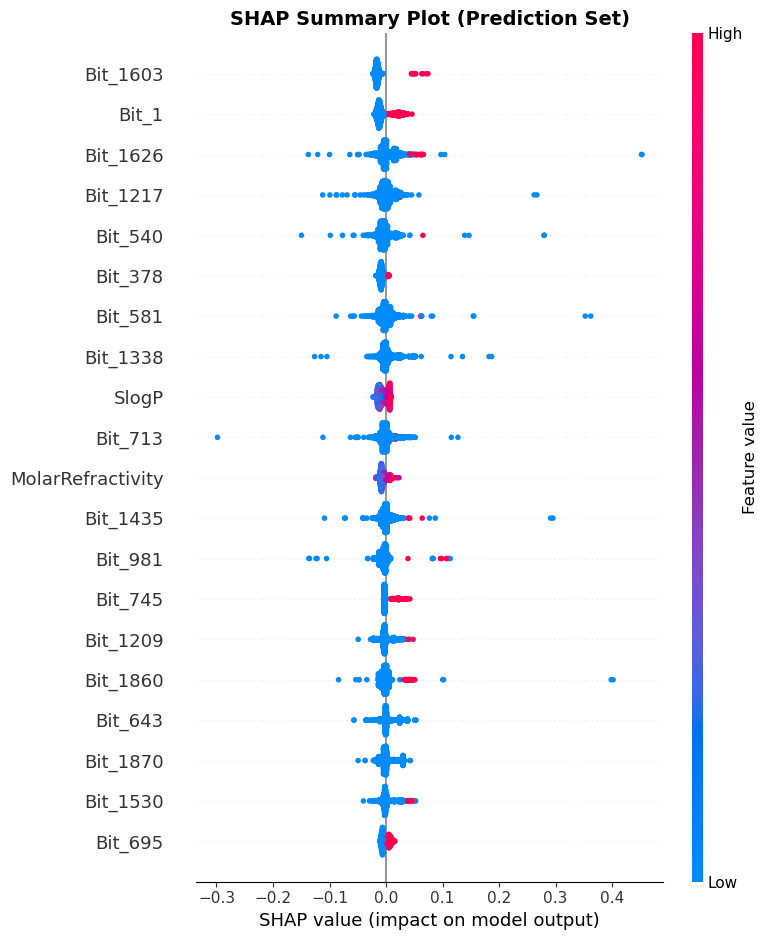

In [51]:
shap.summary_plot(
    shap_active,
    X_prediction,
    max_display=20,
    show=False
)

import matplotlib.pyplot as plt

plt.title(
    "SHAP Summary Plot (Prediction Set)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "Prediction_SHAP_Summary.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

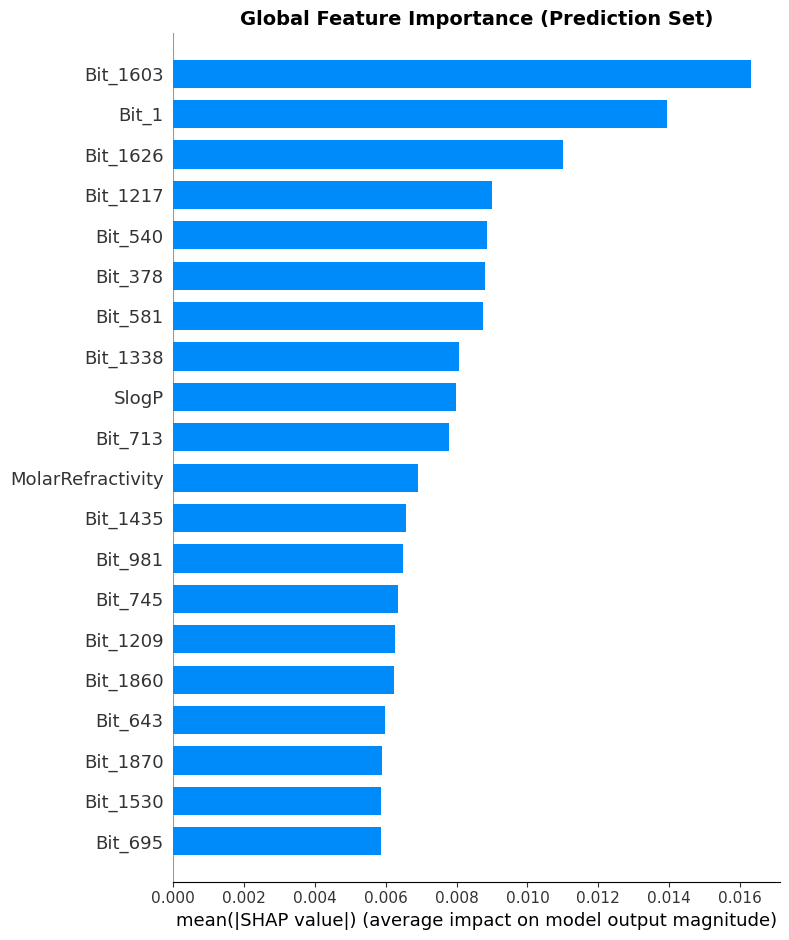

In [52]:
shap.summary_plot(
    shap_active,
    X_prediction,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title(
    "Global Feature Importance (Prediction Set)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "Prediction_SHAP_Bar.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


In [53]:
mean_abs = np.abs(shap_active).mean(axis=0)

feature_importance = pd.DataFrame({

    "Feature":X_prediction.columns,

    "MeanAbsSHAP":mean_abs

})

feature_importance["Feature_Type"] = np.where(

    feature_importance["Feature"].str.startswith("Bit_"),

    "Fingerprint",

    "Descriptor"

)

summary = feature_importance.groupby(
    "Feature_Type"
)["MeanAbsSHAP"].sum().reset_index()

summary["Percentage"] = (
    summary["MeanAbsSHAP"]/
    summary["MeanAbsSHAP"].sum()*100
)

display(summary)

,Feature_Type,MeanAbsSHAP,Percentage
0,Descriptor,0.038565,3.698426
1,Fingerprint,1.004182,96.301574


In [54]:
mean_abs = np.abs(shap_active).mean(axis=0)

feature_importance = pd.DataFrame({

    "Feature":X_prediction.columns,

    "MeanAbsSHAP":mean_abs

})

feature_importance["Feature_Type"] = np.where(

    feature_importance["Feature"].str.startswith("Bit_"),

    "Fingerprint",

    "Descriptor"

)

summary = feature_importance.groupby(
    "Feature_Type"
)["MeanAbsSHAP"].sum().reset_index()

summary["Percentage"] = (
    summary["MeanAbsSHAP"]/
    summary["MeanAbsSHAP"].sum()*100
)

display(summary)

,Feature_Type,MeanAbsSHAP,Percentage
0,Descriptor,0.038565,3.698426
1,Fingerprint,1.004182,96.301574


In [55]:
descriptor_imp = feature_importance[
    feature_importance["Feature_Type"]=="Descriptor"
].sort_values(
    "MeanAbsSHAP",
    ascending=False
)

display(descriptor_imp)

,Feature,MeanAbsSHAP,Feature_Type
2049,SlogP,0.007970,Descriptor
2056,MolarRefractivity,0.006900,Descriptor
2054,AromaticRings,0.005411,Descriptor
2048,MW,0.004306,Descriptor
2057,QED,0.004098,Descriptor
2053,RotatableBonds,0.003267,Descriptor
2051,HBA,0.002805,Descriptor
2050,TPSA,0.001010,Descriptor
2058,HeteroatomRatio,0.000948,Descriptor
2052,HBD,0.000928,Descriptor


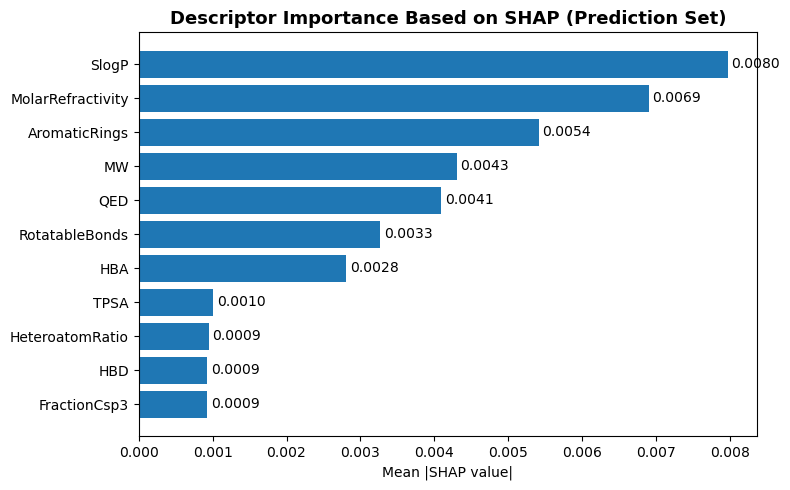

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    descriptor_imp["Feature"][::-1],
    descriptor_imp["MeanAbsSHAP"][::-1]
)

plt.xlabel("Mean |SHAP value|")

plt.title(
    "Descriptor Importance Based on SHAP (Prediction Set)",
    fontsize=13,
    fontweight="bold"
)

for i,v in enumerate(descriptor_imp["MeanAbsSHAP"][::-1]):
    plt.text(v+0.00005,i,f"{v:.4f}",va="center")

plt.tight_layout()

plt.savefig(
    "Prediction_SHAP_Descriptor.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [58]:
import numpy as np
import pandas as pd

# Mean absolute SHAP
mean_abs = np.abs(shap_active).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": X_prediction.columns,
    "Mean_SHAP": mean_abs
})

# Descriptor saja
descriptor_importance = feature_importance[
    ~feature_importance["Feature"].str.startswith("Bit_")
].copy()

descriptor_importance = descriptor_importance.rename(
    columns={"Feature": "Descriptor"}
)

descriptor_importance = descriptor_importance.sort_values(
    "Mean_SHAP",
    ascending=False
)

display(descriptor_importance)

,Descriptor,Mean_SHAP
2049,SlogP,0.007970
2056,MolarRefractivity,0.006900
2054,AromaticRings,0.005411
2048,MW,0.004306
2057,QED,0.004098
2053,RotatableBonds,0.003267
2051,HBA,0.002805
2050,TPSA,0.001010
2058,HeteroatomRatio,0.000948
2052,HBD,0.000928


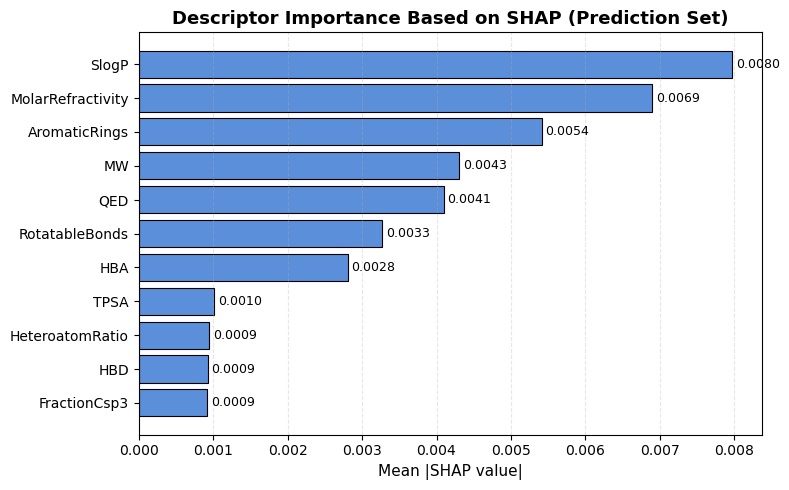

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    descriptor_importance["Descriptor"][::-1],
    descriptor_importance["Mean_SHAP"][::-1],
    color="#5B8FD9",
    edgecolor="black",
    linewidth=0.8
)

plt.xlabel("Mean |SHAP value|", fontsize=11)

plt.title(
    "Descriptor Importance Based on SHAP (Prediction Set)",
    fontsize=13,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

# value pada ujung bar
for i, value in enumerate(descriptor_importance["Mean_SHAP"][::-1]):
    plt.text(
        value + 0.00005,
        i,
        f"{value:.4f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "Figure8_Descriptor_SHAP_Prediction.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [4]:
import pandas as pd

X_prediction = pd.read_csv("X_prediction_hybrid.csv")

print(X_prediction.shape)
display(X_prediction.head())

(1387, 2059)


,Bit_0,Bit_1,Bit_2,Bit_3,Bit_4,Bit_5,Bit_6,Bit_7,Bit_8,Bit_9,...,SlogP,TPSA,HBA,HBD,RotatableBonds,AromaticRings,FractionCsp3,MolarRefractivity,QED,HeteroatomRatio
0,0,1,0,0,0,0,0,0,0,0,...,4.84492,0.00,0,0,4,1,0.466667,68.2590,0.612479,0.000000
1,0,1,0,0,0,0,0,0,0,0,...,5.03540,0.00,0,0,4,0,0.600000,68.9030,0.562992,0.000000
2,0,0,0,0,0,0,0,0,0,0,...,3.17650,29.46,2,1,0,0,0.733333,67.4018,0.652275,0.117647
3,0,1,0,0,0,0,0,0,0,0,...,3.55320,34.14,2,0,1,0,0.733333,69.7310,0.652363,0.117647
4,0,1,0,0,0,0,0,0,1,0,...,3.92720,86.99,5,3,5,0,0.961538,119.0344,0.568647,0.161290


In [5]:
import pandas as pd

prediction = pd.read_csv("prediction_results.csv")
X_prediction = pd.read_csv("X_prediction_hybrid.csv")

In [6]:
prediction["SlogP"] = X_prediction["SlogP"]

In [7]:
prediction[
    ["CID", "Senyawa", "Probability_Active", "SlogP"]
].head()

,CID,Senyawa,Probability_Active,SlogP
0,11575632,Niranthin,0.652,4.84492
1,145455759,His Arg Val,0.642,5.03540
2,135398712,Pheophytin a,0.594,3.17650
3,145455853,His Gly Val,0.592,3.55320
4,145453664,Ala Ser His,0.586,3.92720


In [8]:
summary_plants = prediction[
    prediction["Predicted_Label"] == 1
].sort_values(
    by="Probability_Active",
    ascending=False
).reset_index(drop=True)

display(summary_plants)

,CID,SMILES,InChIKey,PubChem_Status,Senyawa,IC50,Unit,Assay_ID,Assay_Description,Mol,Predicted_Label,Probability_Active,SlogP
0,11575632,COC[C@@H](CC1=CC(=C(C=C1)OC)OC)[C@H](CC2=CC3=C...,RCFGIEPQSDGMJJ-RTBURBONSA-N,FOUND,Niranthin,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.652,4.84492
1,145455759,CC(C)[C@@H](C(=O)O)NC(=O)[C@H](CCCN=C(N)N)NC(=...,TTZAWSKKNCEINZ-AVGNSLFASA-N,FOUND,His Arg Val,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.642,5.03540
2,135398712,CCC1=C(C2=NC1=CC3=C(C4=C([C@@H](C(=C5[C@H]([C@...,FDHFJXKRMIVNCQ-OSIZZBRKSA-N,FOUND,Pheophytin a,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.594,3.17650
3,145455853,CC(C)[C@@H](C(=O)O)NC(=O)CNC(=O)[C@H](CC1=CN=C...,NTXIJPDAHXSHNL-ONGXEEELSA-N,FOUND,His Gly Val,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.592,3.55320
4,145453664,C[C@@H](C(=O)N[C@@H](CO)C(=O)N[C@@H](CC1=CN=CN...,NHWYNIZWLJYZAG-XVYDVKMFSA-N,FOUND,Ala Ser His,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.586,3.92720
5,135407446,CCC\1=C2C=C3C(=C4C(=O)[C@@H](C(=C5[C@H]([C@@H]...,AMVFDCTXPYHACR-KMFDAVQUSA-N,FOUND,Pheophytin b,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.586,2.11700
6,11593175,CCC1=C(C2=NC1=CC3=C(C4=C([N-]3)C(=C5[C@H]([C@@...,NSMUHPMZFPKNMZ-VBYMZDBQSA-M,FOUND,Chlorophyll b,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.572,2.19314
7,185904,C1=CC=C(C=C1)C[C@@H](CO)NC(=O)[C@H](CC2=CC=CC=...,KSVKECXWDNCRTM-GOTSBHOMSA-N,FOUND,aurantiamide,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.568,3.11230
8,12085802,CCC1=C(C2=NC1=CC3=C(C4=C([N-]3)C(=C5[C@H]([C@@...,ATNHDLDRLWWWCB-AENOIHSZSA-M,FOUND,Chlorophyll a,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.546,4.74720
9,162941351,CCC1=C(C2=NC1=CC3=C(C4=C(N3)C(=C5[C@@H]([C@@H]...,PRZIBWPFVNBJRQ-URYQECEPSA-N,FOUND,Aristophyll-C,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.506,3.36130


In [9]:
summary_plants_logp = summary_plants[
    summary_plants["SlogP"] <= 3
].reset_index(drop=True)

display(summary_plants_logp)

,CID,SMILES,InChIKey,PubChem_Status,Senyawa,IC50,Unit,Assay_ID,Assay_Description,Mol,Predicted_Label,Probability_Active,SlogP
0,135407446,CCC\1=C2C=C3C(=C4C(=O)[C@@H](C(=C5[C@H]([C@@H]...,AMVFDCTXPYHACR-KMFDAVQUSA-N,FOUND,Pheophytin b,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.586,2.11700
1,11593175,CCC1=C(C2=NC1=CC3=C(C4=C([N-]3)C(=C5[C@H]([C@@...,NSMUHPMZFPKNMZ-VBYMZDBQSA-M,FOUND,Chlorophyll b,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000027C91F...,1,0.572,2.19314


In [10]:
summary_table = summary_plants[
    [
        "CID",
        "Senyawa",
        "Probability_Active",
        "Domain",
        "SlogP",
        "Nama Tanaman"
    ]
].sort_values(
    by="Probability_Active",
    ascending=False
).reset_index(drop=True)

display(summary_table)

summary_table.to_csv(
    "Top10_Predicted_Active_Herbal.csv",
    index=False
)

KeyError: "['Domain', 'Nama Tanaman'] not in index"

In [11]:
print(prediction.columns.tolist())

['CID', 'SMILES', 'InChIKey', 'PubChem_Status', 'Senyawa', 'IC50', 'Unit', 'Assay_ID', 'Assay_Description', 'Mol', 'Predicted_Label', 'Probability_Active', 'SlogP']


In [12]:
import pandas as pd

herbal = pd.read_csv("dataset herbal.csv")

In [13]:
summary_old = pd.read_csv("predicted_active_herbal_plants_summary.csv")

In [14]:
prediction = prediction.merge(
    summary_old[
        [
            "CID",
            "Domain",
            "Nama Tanaman"
        ]
    ],
    on="CID",
    how="left"
)

In [15]:
summary_table = prediction[
    prediction["Predicted_Label"] == 1
][
    [
        "CID",
        "Senyawa",
        "Probability_Active",
        "Domain",
        "SlogP",
        "Nama Tanaman"
    ]
].sort_values(
    by="Probability_Active",
    ascending=False
).reset_index(drop=True)

summary_table["Probability_Active"] = summary_table["Probability_Active"].round(3)
summary_table["SlogP"] = summary_table["SlogP"].round(2)

display(summary_table)

summary_table.to_csv(
    "Top10_Predicted_Active_Herbal.csv",
    index=False
)

,CID,Senyawa,Probability_Active,Domain,SlogP,Nama Tanaman
0,11575632,Niranthin,0.652,In-domain,4.84,Meniran Hijau
1,145455759,His Arg Val,0.642,Out-of-domain,5.04,Kucing-kucingan
2,135398712,Pheophytin a,0.594,Out-of-domain,3.18,Bangun-bangun
3,145455853,His Gly Val,0.592,Out-of-domain,3.55,Kucing-kucingan
4,145453664,Ala Ser His,0.586,Out-of-domain,3.93,Kucing-kucingan
5,135407446,Pheophytin b,0.586,Out-of-domain,2.12,Bangun-bangun
6,11593175,Chlorophyll b,0.572,Out-of-domain,2.19,"Bayam Merah, Pandan"
7,185904,aurantiamide,0.568,Out-of-domain,3.11,Tanaman Cakar Ayam
8,12085802,Chlorophyll a,0.546,Out-of-domain,4.75,"Bayam Merah, Pandan"
9,162941351,Aristophyll-C,0.506,Out-of-domain,3.36,Bangun-bangun


In [16]:
summary_table = prediction[
    prediction["Predicted_Label"] == 1
][
    [
        "CID",
        "Senyawa",
        "Probability_Active",
        "Domain",
        "SlogP",
        "Nama Tanaman"
    ]
].copy()

summary_table["Probability_Active"] = summary_table["Probability_Active"].round(3)
summary_table["SlogP"] = summary_table["SlogP"].round(2)

summary_table = summary_table.sort_values(
    by="Probability_Active",
    ascending=False
).reset_index(drop=True)

display(summary_table)

summary_table.to_csv(
    "Top10_Predicted_Active_Herbal.csv",
    index=False
)

,CID,Senyawa,Probability_Active,Domain,SlogP,Nama Tanaman
0,11575632,Niranthin,0.652,In-domain,4.84,Meniran Hijau
1,145455759,His Arg Val,0.642,Out-of-domain,5.04,Kucing-kucingan
2,135398712,Pheophytin a,0.594,Out-of-domain,3.18,Bangun-bangun
3,145455853,His Gly Val,0.592,Out-of-domain,3.55,Kucing-kucingan
4,145453664,Ala Ser His,0.586,Out-of-domain,3.93,Kucing-kucingan
5,135407446,Pheophytin b,0.586,Out-of-domain,2.12,Bangun-bangun
6,11593175,Chlorophyll b,0.572,Out-of-domain,2.19,"Bayam Merah, Pandan"
7,185904,aurantiamide,0.568,Out-of-domain,3.11,Tanaman Cakar Ayam
8,12085802,Chlorophyll a,0.546,Out-of-domain,4.75,"Bayam Merah, Pandan"
9,162941351,Aristophyll-C,0.506,Out-of-domain,3.36,Bangun-bangun


In [17]:
summary_table_logp = summary_table[
    summary_table["SlogP"] <= 3
].reset_index(drop=True)

display(summary_table_logp)

summary_table_logp.to_csv(
    "Top_Candidates_After_LogP_Filter.csv",
    index=False
)

,CID,Senyawa,Probability_Active,Domain,SlogP,Nama Tanaman
0,135407446,Pheophytin b,0.586,Out-of-domain,2.12,Bangun-bangun
1,11593175,Chlorophyll b,0.572,Out-of-domain,2.19,"Bayam Merah, Pandan"


In [18]:
summary_table_logp.insert(
    0,
    "Rank",
    range(1, len(summary_table_logp) + 1)
)

display(summary_table_logp)

,Rank,CID,Senyawa,Probability_Active,Domain,SlogP,Nama Tanaman
0,1,135407446,Pheophytin b,0.586,Out-of-domain,2.12,Bangun-bangun
1,2,11593175,Chlorophyll b,0.572,Out-of-domain,2.19,"Bayam Merah, Pandan"


In [19]:
herbal = pd.read_csv("dataset herbal.csv")

summary_table = summary_table.merge(
    herbal[
        [
            "CID",
            "Nama Tanaman",
            "Bagian Tanaman"
        ]
    ].drop_duplicates("CID"),
    on="CID",
    how="left"
)

KeyError: "['CID'] not in index"